# Customer Sentiment Analysis

#
# Task 1:
### 1. Data Collection (Web Scraping):

##### Importing Required Libraries

In [ ]:
from bs4 import BeautifulSoup
import requests 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

Names = []
Rating = []
Reviews = []
Cities = []
Occasions = []
Posted_On = []

#### Web Scraping and HTML parsing usning BeautifulSoup

In [ ]:
url = "https://www.floweraura.com/reviews/p/6617/10-red-roses-bouquet?page="
#url = "https://www.floweraura.com/reviews/p/10172/divine-butterscotch-cake?page="

for i in range(1,51):
    cnp = url+str(i)
    url_new = cnp
    r = requests.get(url_new)
    
    soup = BeautifulSoup(r.text, "html.parser")
    
    main = soup.find("div", {"class":"review-left-container"})
    
    sub = main.find_all("div", {"class":"new-review-card-container"})
    
    for i in sub:
        name = i.find("span", {"class":"review-author-name"})
        Names.append(name.text.title())
    
        city = i.find_all("span", {"class":"review-meta-details"})
        Cities.append(city[0].text.title())
        try:
            Occasions.append(city[1].text.title())
        except:
            Occasions.append(np.nan)
            
        date = i.find_all("span")
        try:
            Posted_On.append(date[4].text)
        except:
            Posted_On.append(np.nan)
    
        rating = i.find("span", {"class":"star-count-container"})
        Rating.append(rating.text)
    
        review = i.find_all("div")
        Reviews.append(review[-1].text)


In [ ]:
df = pd.DataFrame({'Names':Names, "Citites":Cities, "Posted_On":Posted_On, "Occasion":Occasions, "Ratings":Rating, "Reviews":Reviews})
df.to_csv("Flower_aura_product_reviews.csv")

##### Before loading the dataset to perform analysis, performed some columns renaming and indexing

In [ ]:
df = pd.read_csv("Flower_aura_product_reviews.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)
df.rename(columns={"Citites": "Cities"}, inplace=True)
df.to_csv("Flower_aura_product_reviews_cleaned.csv", index=False)

#
# Task 2
# Data Cleaning and Preprocessing:

In [4]:
#Load the Dataset
df = pd.read_csv("Flower_aura_product_reviews_cleaned.csv")
df.head()

,Names,Cities,Posted_On,Occasion,Ratings,Reviews
0,Your Love,Pune,Posted On : 6th Jun 2026,Occassion : Valentines Day,5,Fresh flowers were delivered
1,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,Great experience with FlowerAura.Delivery was ...
2,Anki M,Shillong,Posted On : 21st Oct 2025,NaN,5,Fresh flowers...liked it.
3,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful. TBH they ...
4,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,"Very fresh flowers, delivered on time with bea..."


## Step 1:
#### Remove duplicates: Eliminate any duplicate reviews to ensure data quality.

In [5]:
df.duplicated().sum()

np.int64(0)

##### No duplicate value found

## Step 2:
#### Handle missing values: Address missing or incomplete data, such as missing review text or rating, by either removing rows or filling in missing values if applicable.

In [6]:
df.isnull().sum()

Names          0
Cities         0
Posted_On      0
Occasion     110
Ratings        0
Reviews       17
dtype: int64

##### Columns named Occasion and Reviews have null values.

##### We cannot determine the sentiment without the Review, so we have to remove the rows with empty Reviews.
##### and for Occasion we fill it with "Unknown" using fillna()

In [7]:
df["Occasion"] = df["Occasion"].fillna("Unknown")

df.dropna(subset=["Reviews"], inplace=True)

In [8]:
df.isnull().sum()

Names        0
Cities       0
Posted_On    0
Occasion     0
Ratings      0
Reviews      0
dtype: int64

#
## Text Preprocessing:

### Step 1: Convert the review text to lowercase.

In [9]:
df["Reviews"] = df["Reviews"].str.lower()

df["Reviews"].head()

0                         fresh flowers were delivered
1    great experience with floweraura.delivery was ...
2                            fresh flowers...liked it.
3    the flowers were fresh and colorful. tbh they ...
4    very fresh flowers, delivered on time with bea...
Name: Reviews, dtype: object

### Step 2: Remove irrelevant characters (e.g., special characters, punctuation, and extra spaces).

In [10]:
import re

df["Reviews"] = df["Reviews"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x))
)

df["Reviews"] = df["Reviews"].str.replace(r'\s+', ' ', regex=True).str.strip()

df["Reviews"].head()

0                         fresh flowers were delivered
1    great experience with flowerauradelivery was o...
2                                fresh flowersliked it
3    the flowers were fresh and colorful tbh they w...
4    very fresh flowers delivered on time with beau...
Name: Reviews, dtype: object

### Step 3: Tokenize the text into individual words.

In [11]:
df["Tokens"] = df["Reviews"].apply(word_tokenize)

df["Tokens"].head()

0                    [fresh, flowers, were, delivered]
1    [great, experience, with, flowerauradelivery, ...
2                            [fresh, flowersliked, it]
3    [the, flowers, were, fresh, and, colorful, tbh...
4    [very, fresh, flowers, delivered, on, time, wi...
Name: Tokens, dtype: object

### Step 4: Remove stop words (commonly used words that do not add significant meaning to sentiment analysis).

In [12]:
stop_words = set(stopwords.words("english"))

df["Tokens"] = df["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df["Tokens"].head()

0                          [fresh, flowers, delivered]
1    [great, experience, flowerauradelivery, time, ...
2                                [fresh, flowersliked]
3    [flowers, fresh, colorful, tbh, better, expect...
4    [fresh, flowers, delivered, time, beautiful, p...
Name: Tokens, dtype: object

### Step 5: Perform lemmatization to convert words into their base form (e.g., "running" → "run").

In [13]:
lemmatizer = WordNetLemmatizer()

df["Tokens"] = df["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df["Tokens"].head()

0                           [fresh, flower, delivered]
1    [great, experience, flowerauradelivery, time, ...
2                                [fresh, flowersliked]
3    [flower, fresh, colorful, tbh, better, expecte...
4    [fresh, flower, delivered, time, beautiful, pa...
Name: Tokens, dtype: object

#
# Task 3
## Sentiment Analysis:

#
## Step 1:
#### Use TextBlob to perform sentiment analysis on the review text.
#### TextBlob will provide a polarity score between -1 (negative) and +1 (positive), as well as a subjectivity score.

In [14]:
from textblob import TextBlob

def polarity(review):
    return TextBlob(review).sentiment.polarity

df["Polarity"] = df["Reviews"].apply(polarity)

df[["Reviews","Polarity"]].head()

,Reviews,Polarity
0,fresh flowers were delivered,0.300000
1,great experience with flowerauradelivery was o...,0.452381
2,fresh flowersliked it,0.300000
3,the flowers were fresh and colorful tbh they w...,0.240000
4,very fresh flowers delivered on time with beau...,0.532381


#
## Step 2:
#### Define a threshold to classify the sentiment:
#### Positive sentiment: Polarity score ≥ 0.1
#### Negative sentiment: Polarity score < 0.1

In [16]:
def sentiment(score):

    if score >= 0.1:
        return "Positive"
    else:
        return "Negative"

df["Sentiment"] = df["Polarity"].apply(sentiment)

df[["Reviews","Polarity","Sentiment"]].head()

,Reviews,Polarity,Sentiment
0,fresh flowers were delivered,0.300000,Positive
1,great experience with flowerauradelivery was o...,0.452381,Positive
2,fresh flowersliked it,0.300000,Positive
3,the flowers were fresh and colorful tbh they w...,0.240000,Positive
4,very fresh flowers delivered on time with beau...,0.532381,Positive


In [17]:
df["Sentiment"].value_counts()

Sentiment
Positive    424
Negative     59
Name: count, dtype: int64

#
## Step 3:
#### Store the sentiment classification for each review in the dataset.

In [18]:
df.to_csv("Flower_aura_sentiment_analysis.csv", index=False)

In [19]:
df

,Names,Cities,Posted_On,Occasion,Ratings,Reviews,Tokens,Polarity,Sentiment
0,Your Love,Pune,Posted On : 6th Jun 2026,Occassion : Valentines Day,5,fresh flowers were delivered,"[fresh, flower, delivered]",0.300000,Positive
1,Ramesh Kumar Pariyar,Bengaluru,Posted On : 7th Jan 2026,Occassion : Birthday,5,great experience with flowerauradelivery was o...,"[great, experience, flowerauradelivery, time, ...",0.452381,Positive
2,Anki M,Shillong,Posted On : 21st Oct 2025,Unknown,5,fresh flowersliked it,"[fresh, flowersliked]",0.300000,Positive
3,Suraj Chaunal,Noida,Posted On : 23rd Sep 2025,Occassion : Birthday,5,the flowers were fresh and colorful tbh they w...,"[flower, fresh, colorful, tbh, better, expecte...",0.240000,Positive
4,Bakiyalakshmi,Bangalore,Posted On : 22nd Sep 2025,Occassion : Anniversary,5,very fresh flowers delivered on time with beau...,"[fresh, flower, delivered, time, beautiful, pa...",0.532381,Positive
...,...,...,...,...,...,...,...,...,...
495,Srinivasan.Nagarajan,Coimbatore,Posted On : 11th Sep 2023,Unknown,5,good,[good],0.700000,Positive
496,Sumiit Bhatia,Goa,Posted On : 10th Sep 2023,Unknown,5,good,[good],0.700000,Positive
497,Jidhu Joshua,Jodhpur,Posted On : 10th Sep 2023,Occassion : Anniversary,5,it was amazing,[amazing],0.600000,Positive
498,Arun,Hyderabad,Posted On : 9th Sep 2023,Unknown,4,thanks for the flowers,"[thanks, flower]",0.200000,Positive


#
# Task 4
### 4. Data Analysis and Insights:

#
### Step 1:
#### Sentiment Distribution: Calculate the overall distribution of positive and negative sentiments for the 300 reviews.

In [21]:
# Number of reviews in each sentiment category
sentiment_counts = df["Sentiment"].value_counts()

sentiment_counts

Sentiment
Positive    424
Negative     59
Name: count, dtype: int64

In [22]:
# Percentage of each sentiment
sentiment_percentage = round((df["Sentiment"].value_counts(normalize=True) * 100), 2)

sentiment_percentage

Sentiment
Positive    87.78
Negative    12.22
Name: proportion, dtype: float64

#
### Step 2:
#### Average Rating vs Sentiment: Analyze if there is any correlation between the numeric ratings (1-5 stars) and sentiment polarity. Do higher ratings correspond with more positive sentiments?

In [24]:
# The average rating for each sentiment
average_rating = df.groupby("Sentiment")["Ratings"].mean().round(2)

average_rating

Sentiment
Negative    4.86
Positive    4.90
Name: Ratings, dtype: float64

In [25]:
rating_sentiment = df.groupby(["Ratings", "Sentiment"]).size().unstack(fill_value=0)

rating_sentiment

Sentiment,Negative,Positive
Ratings,,
1,0,1
2,1,0
3,0,3
4,5,34
5,53,386


In [28]:
correlation = df["Ratings"].corr(df["Polarity"])

print("Correlation between Ratings and Polarity:", round(correlation, 3))

Correlation between Ratings and Polarity: -0.003


#### Observation:
##### The average ratings for both positive (4.90) and negative (4.86) sentiments are very similar. This suggests that customer ratings do not always perfectly match the sentiment extracted from the review text, as many reviews received high ratings regardless of their predicted sentiment.

#
### Step 3:
#### Word Cloud: Create a word cloud to identify the most frequently mentioned words in the positive and negative reviews.

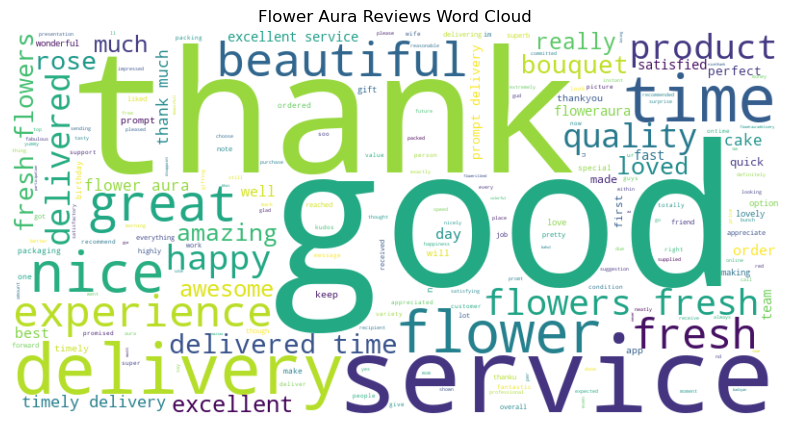

In [31]:
# word cloud

import re
from wordcloud import STOPWORDS

text = ' '.join(df['Reviews'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Flower Aura Reviews Word Cloud")
plt.show()

#
### Step 4:
#### Review Length Analysis: Investigate if longer reviews are associated with more detailed sentiments, either positive or negative.

In [34]:
# Number of words in each cleaned review
df["Review_Length"] = df["Reviews"].apply(lambda x: len(str(x).split()))

df[["Reviews", "Review_Length"]].head()

,Reviews,Review_Length
0,fresh flowers were delivered,4
1,great experience with flowerauradelivery was o...,19
2,fresh flowersliked it,3
3,the flowers were fresh and colorful tbh they w...,14
4,very fresh flowers delivered on time with beau...,17


In [35]:
average_length = df.groupby("Sentiment")["Review_Length"].mean().round(2)

average_length

Sentiment
Negative    5.75
Positive    6.66
Name: Review_Length, dtype: float64

#### Observation:
##### Positive reviews have an average length of 6.66 words, while negative reviews average 5.75 words. This indicates that positive reviews are generally slightly longer, suggesting customers with positive experiences tend to provide more detailed feedback

#
## Recommendations:
##### Improve delivery service to reduce delays and provide a better customer experience.
##### Maintain the quality of flowers, as most customers were satisfied with them.
##### Improve the quality of cakes and other products based on customer feedback.
##### Use positive customer reviews in advertisements and on the website to attract more customers.
##### Encourage customers to write detailed reviews to better understand their experience.

## Conclusion:
##### The sentiment analysis shows that most customers are satisfied with FlowerAura's products and services. By improving delivery and product quality while promoting positive customer feedback, FlowerAura can further increase customer satisfaction and attract more customers.